# Musterlösung 9

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def PMF(data, resolution):
    # Definieren der Bins und Berechnen des Histogramms
    # Wir addieren resolution / 1000 zur Obergrenze, um sicherzustellen, dass der letzte Wert auch im Array ist.
    bin_centers = np.arange(np.min(data), np.max(data) + resolution / 1000, resolution)
    bin_edges = np.linspace(bin_centers[0] - resolution / 2,
                            bin_centers[-1] + resolution / 2,
                            len(bin_centers) + 1)
    
    hist, _ = np.histogram(data, bin_edges)
    
    # Normieren
    px = hist / np.sum(hist)
    
    return bin_centers, px

## Aufgabe 1

In dieser Aufgabe werden wir uns mit der Gaussschen Normalverteilung vertraut machen. Dazu werden wir Daten analysieren, die aus einer Normalverteilung stammen, und diese plotten.\
Zur Erinnerung: Die Wahrscheinlichkeitsdichtefunktion der Gaussschen Normalverteilung ist definiert als $$ f(x) = {1 \over \sqrt{2\pi\sigma^2}} e^{-{1 \over 2}{(x-\mu)^2 \over \sigma^2}}$$

### a)
Ihre Aufgabe besteht darin, eine Funktion zu vervollständigen, die die Wahrscheinlichkeitsmassefunktion (PMF) einer Normalverteilung an den Stellen der Werte im Vektor x zurückgibt. Die Normalverteilung soll dabei einen Mittelwert `mu` und eine Standardabweichung `sigma` haben.
\
**Hinweis:** Die Wahrscheinlichkeitsdichtefunktion und die Wahrscheinlichkeitsmassefunktion unterscheiden sich in einem kleinen Detail der Implementierung

### Lösung

In [2]:
def normal_pmf(x, mu, sigma, binsize):
    # Wir approximieren die PMF der Gausschen Normalverteilung. Warum dies lediglich eine 
    # Approximation ist, ist im Zusatz Notebook Histogramme beschrieben.
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-1/2*((x-mu)**2/(sigma**2)))*binsize

### b)
Ziehen Sie 1000 Werte aus einer Normalverteilung (Sie können dazu die Funktion `numpy.random.normal` verwenden). Plotten Sie das Histogramm dieser Zufallswerte und überlagern Sie einen Plot der entsprechenden PMF mit denselben Parametern. Zur Darstellung der PMF der Zufallswerte können Sie die oben definierte PMF-Funktion verwenden.\
\
Ändern Sie die Anzahl der Zufallswerte, die Sie für Ihr Histogramm verwenden, um ein Gefühl zu erhalten, wie die Verteilung mit zunehmender Anzahl an Datenpunkten immer besser die Normalverteilung abbildet.

### Lösung

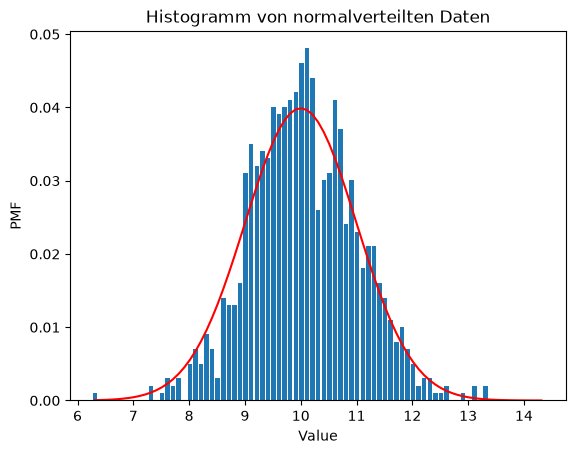

In [ ]:
mu = 10
sigma = 1
# Wir ziehen Samples aus einer Gaussschen Normalverteilung mit Mittelwert mu und Standardabweichung sigma. 
normal_data = np.random.normal(mu, sigma, 1000)

binsize = 0.1
x, px = PMF(normal_data, binsize)
plt.figure()
plt.bar(x, px, width=0.08)
plt.xlabel('Value')
plt.ylabel('PMF')
plt.title('Histogramm von normalverteilten Daten')

# Überlagern des Histogramms mit der erwarteten PMF der gezogenen Daten.
plt.plot(x,normal_pmf(x,mu,sigma,binsize),'r')

## Aufgabe 2: Zentraler Grenzwertsatz

Der zentrale Grenzwertsatz ist ein wichtiges Resultat der Wahrscheinlichkeitstheorie. Wie in der Vorlesung vermittelt besagt er, dass sich die Verteilung der Mittelwerte von Stichproben einer Gaussschen Normalverteilung annähern werden, sofern die Zufallsvariablen unabhängig und identisch verteilt sind. Dies ist unabhängig von der Verteilung der unterliegenden Daten.

In der Datei 'NASA_small_body_data_period.txt' sind die Umlaufzeiten der meisten bekannten kleineren Objekte in unserem Sonnensystem enthalten. Im folgenden werden wir uns mit derer Verteilung beschäftigen. 

### a)

Laden Sie den Datensatz 'NASA_small_body_data_period.txt', und stellen Sie die Verteilung der Umlaufzeiten in einem Plot dar. Wie würden Sie diese Verteilung beschreiben? Ist diese Verteilung eine Gaussche Normalverteilung? Wenn ja, was ist deren Mittelwert und Standardabweichung? Wenn nein, haben Sie eine Idee warum dies nicht der Fall ist?


### Lösung

Text(0.5, 1.0, 'Umlaufzeiten der kleinen Objekte im Sonnensystem')

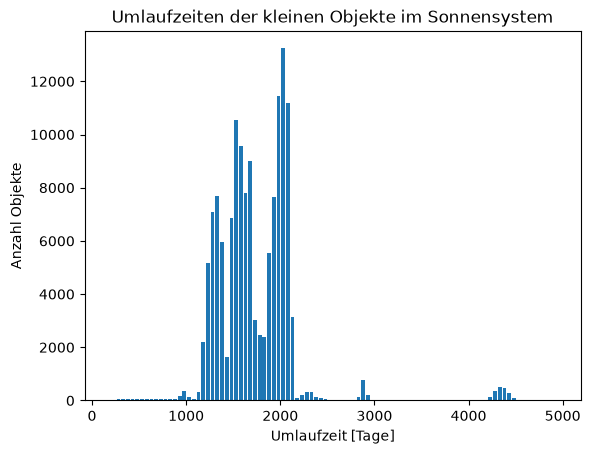

Die Umlaufzeiten sind nicht Normalverteilt. Dies kommt daher, dass Himmelskörper, welche eine Umlaufzeit haben, die im Vergleich zu derjeniger von Jupiter als Verhältnis natürlicher Zahlen beschrieben werden kann, in eine instabile Resonanzbedingung mit diesem eingehen und solange durch Austausch von Impuls mit Jupiter beschleunigt oder gebremst werden, bis sie diese Resonanzbedingung verlassen haben. Mehr Informationen dazu können Sie unter dem folgenden Link finden: [NASA](https://ssd.jpl.nasa.gov/diagrams/mb_hist.html)

### b)

Im nächsten Schritt möchten wir den zentralen Grenzwertsatz auf diese Daten anwenden. Dazu gehen Sie folgendermaßen vor:

1. Ziehen Sie eine Stichprobe mit 500 Objekten aus den gegebenen Daten.
2. Berechnen Sie den Mittelwert dieser Stichprobe und speichern Sie diesen in einem NumPy-Array.
3. Wiederholen Sie dieses Verfahren 250-mal.

Gemäss dem zentralen Grenzwertsatz sollte sich die Verteilung dieser Mittelwerte der Stichproben einer Gaussverteilung annähern.

Um dies zu überprüfen, befolgen Sie das oben genannte Vorgehen. Plotten Sie als nächstes die Verteilung der Mittelwerte der Stichproben mittels eines Histogramms.

In der Vorlesung haben Sie gelernt, dass der erwartete Mittelwert und die Standardabweichung der Normalverteilung aus den Ursprungsdaten berechnet werden können.\
Tun Sie dies und überlagern Sie diese erwartete Normalverteilung mit dem bereits geplotteten Histogramm.


### Lösung

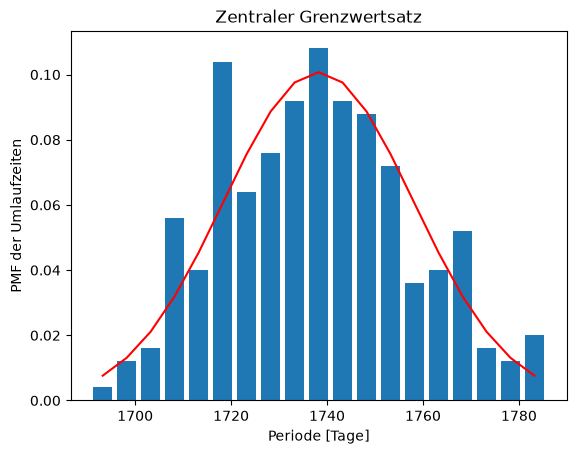

In [8]:
sample_size = 500

number_of_samples = 250

sample_means = np.zeros(number_of_samples)

for i in range(number_of_samples):
    # Ziehe die richtige Anzahl an zufälligen Datenpunkten aus den Ursprungsdaten und 
    # berechne den Mittelwert dieser Samples.
    sample = np.random.choice(data, size=sample_size, replace=False)
    sample_means[i] = np.mean(sample)

resolution = 5
x, px = PMF(sample_means, resolution)

# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Periode [Tage]')
plt.ylabel('PMF der Umlaufzeiten')
plt.title('Zentraler Grenzwertsatz')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
plt.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')


Laut dem Zentralen Grenzwertsatz erwarten wir eine Normalverteilung der Mittelwerte der Stichproben. Dabei ist der Mittelwert dieser Verteilung der Mittelwert des ursprünglichen Datensatzes. Die erwartete Standardabweichung ist die Standardabweichung der Ursprungsdaten, geteilt durch die Grösse der Stichproben.

### c)

Wiederholen Sie dies für den Fall, dass Sie 2, 10, 100, 1000 Werte pro Stichprobe nehmen. Stellen Sie das Ergebnis in einer Abbildung mit 4 Untergrafiken dar. Was fällt dabei auf? Wie verhält sich das Histogramm der Stichproben im Vergleich zur erwarteten Normalverteilung?\
Ändern Sie zusätzlich die Anzahl der Stichproben. Welchen Effekt hat dies?

In [ ]:
n_samples_list = np.array([2, 10, 100, 1000])
number_of_samples = 500

### Lösung

Text(0.5, 0.98, 'Unterschiedliche Anzahl an Werten pro Stichprobe')

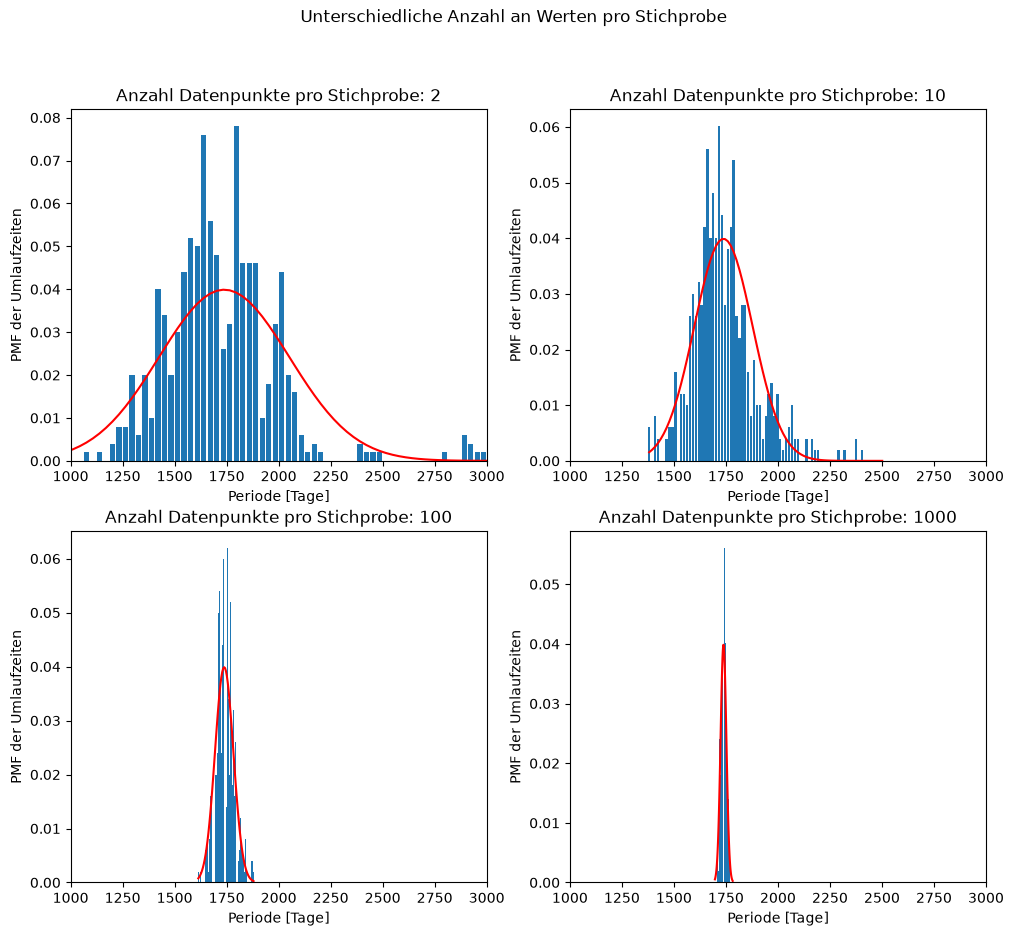

In [ ]:
cm = 0.393701


fig = plt.figure(figsize=(30*cm, 25.5*cm))

# Wir erzeugen die Histogramme und Plots für die verschiedene Anzahl an Datenpunkten in einer for-Schleife, da
# der Code immer der gleiche ist.
for idx, sample_size in enumerate(n_samples_list):
    sample_means = np.zeros(number_of_samples)

    for i in range(number_of_samples):
        sample = np.random.choice(data, size=sample_size, replace=False)
        sample_means[i] = np.mean(sample)
        
    meanPeriod = np.mean(data)
    stdPeriod = np.std(data)/np.sqrt(sample_size)
    # Histogramm erzeugen
    resolution = stdPeriod/10
    x, px = PMF(sample_means, resolution)
    
    # Plotten
    ax = fig.add_subplot(2, 2, idx+1)
    ax.bar(x, px, width=0.8*resolution)
    ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
    ax.set_xlabel('Periode [Tage]')
    ax.set_ylabel('PMF der Umlaufzeiten')
    ax.set_title('Anzahl Datenpunkte pro Stichprobe: {:.0f}'.format(sample_size))
    ax.set_xlim([1000,3000])
fig.suptitle("Unterschiedliche Anzahl an Werten pro Stichprobe")

Wenn die Anzahl der Datenpunkte pro Stichpunkt erhöht wird, führt dies zu einer Reduzierung der Standardabweichung der resultierenden Normalverteilung. Um dies zu verdeutlichen, wurden oben alle vier Plots über das gleiche x-Achsen Intervall geplottet.

Text(0.5, 0.98, 'Unterschiedliche Anzahl an Stichproben')

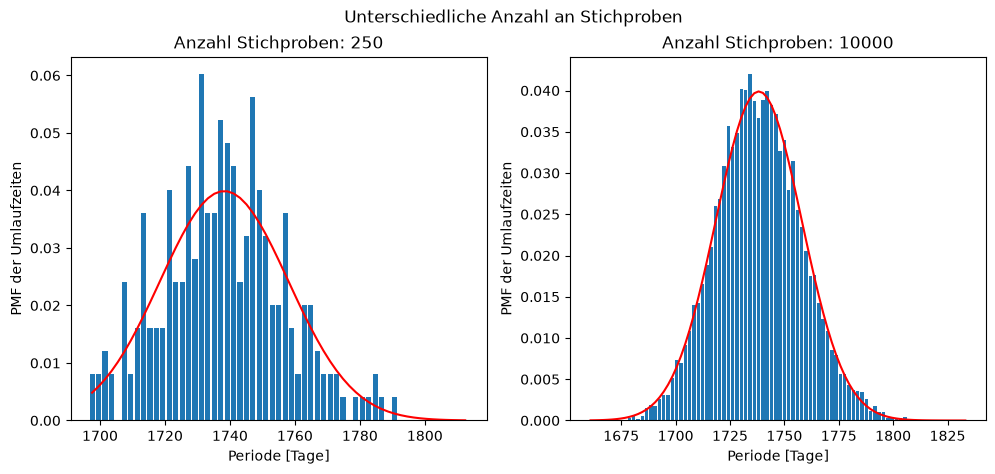

In [ ]:
#Nun ändern wir die Anzahl samples, behalten jedoch die Samplegrösse von 500 Datenpunkten pro Sample

sample_size = 500
number_of_samples_list = np.array([250, 10000])

fig2 = plt.figure(figsize=(30*cm, 12*cm))

# Wir erzeugen die Histogramme und Plots für die verschiedene Anzahl an Datenpunkten in einer for-Schleife, da
# der Code immer der gleiche ist.
for idx, number_of_samples in enumerate(number_of_samples_list):
    sample_means = np.zeros(number_of_samples)

    for i in range(number_of_samples):
        sample = np.random.choice(data, size=sample_size, replace=False)
        sample_means[i] = np.mean(sample)
        
    meanPeriod = np.mean(data)
    stdPeriod = np.std(data)/np.sqrt(sample_size)
    # Histogramm erzeugen
    resolution = stdPeriod/10
    x, px = PMF(sample_means, resolution)
    
    # Plotten
    ax = fig2.add_subplot(1, 2, idx+1)
    ax.bar(x, px, width=0.8*resolution)
    ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
    ax.set_xlabel('Periode [Tage]')
    ax.set_ylabel('PMF der Umlaufzeiten')
    ax.set_title('Anzahl Stichproben: {:.0f}'.format(number_of_samples))
fig2.suptitle("Unterschiedliche Anzahl an Stichproben")

Wenn hingegen die Anzahl der Stichproben erhöht wird, führt dies zu einer verbesserten Übereinstimmung mit der erwarteten Verteilung.

### d)

Um das Ziehen der Stichproben effizienter zu gestalten, stellen wir Ihnen den folgenden Code zur Verfügung:

In [ ]:
def draw_samples(data, sample_size, number_of_samples):
    start_points = np.random.randint(0, data.size-sample_size, size=(1,number_of_samples))
    drawn_indices = np.squeeze(np.linspace(start_points, start_points + sample_size-1 ,sample_size))
    sample_data = data[drawn_indices.astype(int)]
    
    return sample_data

Ziehen Sie 1000 Stichproben, wobei jede Stichprobe aus 5000 Objekten besteht, und plotten Sie die Verteilung der Mittelwerte dieser Stichproben. Was fällt Ihnen dabei auf? Können Sie dieses Verhalten erklären?

In [12]:
sample_size = 5000
number_of_samples = 1000

### Lösung

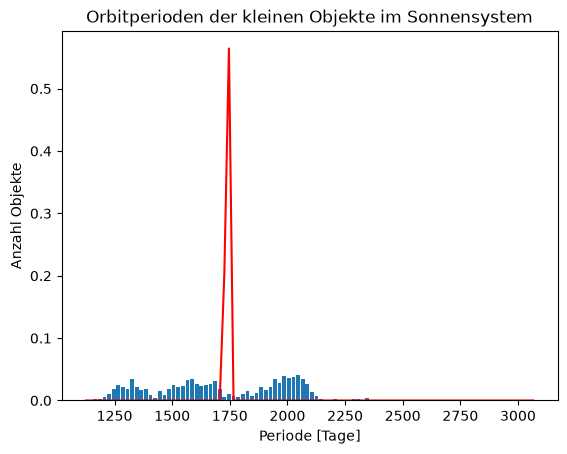

In [ ]:
resolution = 20
samples = draw_samples(data, sample_size, number_of_samples)
sample_means = np.mean(samples, axis=0)

x, px = PMF(sample_means, resolution)
# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Periode [Tage]')
plt.ylabel('Anzahl Objekte')
plt.title('Orbitperioden der kleinen Objekte im Sonnensystem')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
plt.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')


Eine der fundamentalen Annahmen des zentralen Grenzwertsatzes ist, dass die Stichproben unabhängig und identisch verteilt sind. Die oben gezeigte draw_samples Funktion wählt zwar zufällig gewählte Startwerte für jede Stichprobe, der Inhalt der Stichprobe sind allerdings die folgenden Indizes. Dadurch sind die Stichproben nicht mehr unabhängig (dies wird dadurch verstärkt, dass der Inhalt der Ursprungsdaten aufsteigend sortiert ist) und der zentrale Grenzwertsatz kann nicht mehr angewendet werden.